In [ ]:
!pip install ucimlrepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

In [ ]:
heart_disease = fetch_ucirepo(id=45)
X_raw = heart_disease.data.features  # Features
y_raw = heart_disease.data.targets   # Targets (column: 'num')

# metadata (optional print)
print(heart_disease.metadata)

# variable information (optional print)
print(heart_disease.variables)

# Combine into single dataframe for easier preprocessing (matching original code)
dataset = pd.concat([X_raw, y_raw], axis=1)

dataset = dataset.dropna()
dataset['num']=np.where(dataset['num']==0,-1,1)
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [ ]:
dataset['num'].unique()

array([-1,  1])

In [ ]:
print(dataset['num'].value_counts())
dataset.head()

num
-1    160
 1    137
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,-1
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,-1
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,-1


In [ ]:
dataset['num'].value_counts(normalize=True)

,proportion
num,
-1,0.538721
1,0.461279


<Axes: ylabel='Frequency'>

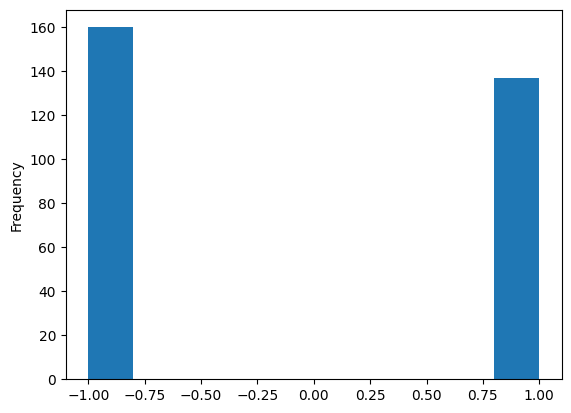

In [ ]:
dataset['num'].plot.hist()

In [ ]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,3.158249,0.964859,1.0,3.0,3.0,4.0,4.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=24,shuffle=True)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
print(X_train[227])
sc=MinMaxScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)
xmin = sc.data_min_
xmax = sc.data_max_
print(X_train[227])
print(xmin)
print(xmax)
X_train_df = pd.DataFrame(X_train)

# Add target column
X_train_df['Target'] = y_train.values if hasattr(y_train, 'values') else y_train

# Print first 5 rows
print(X_train_df.head())

[ 48.   1.   3. 124. 255.   1.   0. 175.   0.   0.   1.   2.   3.]
[0.39583333 1.         0.66666667 0.28301887 0.29452055 1.
 0.         0.76315789 0.         0.         0.         0.66666667
 0.        ]
[ 29.   0.   1.  94. 126.   0.   0.  88.   0.   0.   1.   0.   3.]
[ 77.    1.    4.  200.  564.    1.    2.  202.    1.    6.2   3.    3.
   7. ]
          0    1         2         3         4    5    6         7    8  \
0  0.708333  0.0  1.000000  0.283019  0.162100  0.0  0.0  0.421053  1.0   
1  0.666667  1.0  0.000000  0.377358  0.246575  0.0  0.0  0.500000  0.0   
2  0.104167  1.0  0.000000  0.226415  0.127854  0.0  1.0  0.754386  0.0   
3  0.854167  1.0  0.333333  0.584906  0.271689  0.0  1.0  0.482456  0.0   
4  0.729167  1.0  0.000000  0.716981  0.230594  0.0  1.0  0.587719  0.0   

          9   10        11   12  Target  
0  0.000000  0.5  0.000000  0.0       1  
1  0.419355  0.5  0.666667  0.0       1  
2  0.000000  0.0  0.000000  0.0      -1  
3  0.000000  0.0  0.000000  

In [ ]:
xtrain_samples=X_train.shape[0]
xtest_samples=X_test.shape[0]
print(f'There are {xtrain_samples} samples for training and {xtest_samples} samples for testing')

There are 237 samples for training and 60 samples for testing


In [ ]:
from sklearn.svm import SVC
svc=SVC(kernel='poly',degree=3,gamma=2)
svc.fit(X_train,y_train)

SVC(gamma=2, kernel='poly')

In [ ]:
y_pred=svc.predict(X_test)

              precision    recall  f1-score   support

          -1       0.63      0.63      0.63        27
           1       0.70      0.70      0.70        33

    accuracy                           0.67        60
   macro avg       0.66      0.66      0.66        60
weighted avg       0.67      0.67      0.67        60



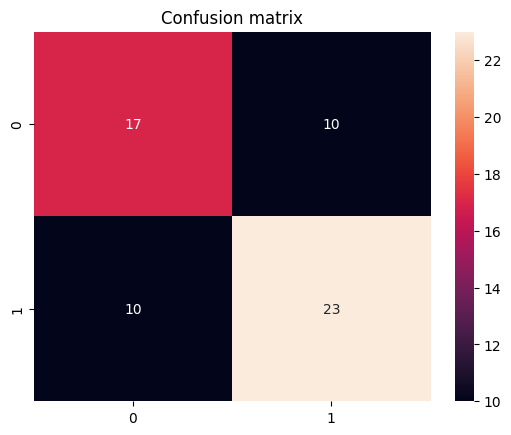

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d').set_title('Confusion matrix')
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.99      1.00      1.00       133
           1       1.00      0.99      1.00       104

    accuracy                           1.00       237
   macro avg       1.00      1.00      1.00       237
weighted avg       1.00      1.00      1.00       237



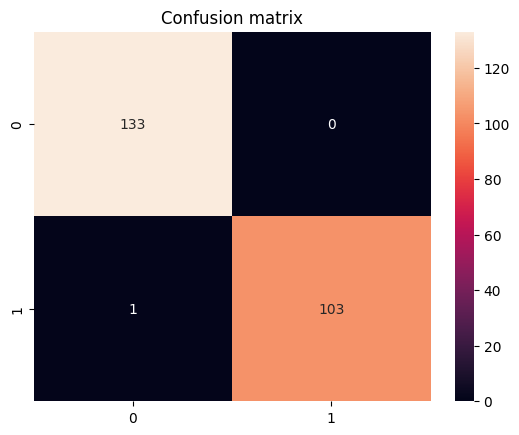

In [ ]:
y_pred_train=svc.predict(X_train)
cm=confusion_matrix(y_train,y_pred_train)
sns.heatmap(cm,annot=True,fmt='d').set_title('Confusion matrix')
print(classification_report(y_train,y_pred_train))

In [ ]:
svc.get_params()
print(svc.n_support_)

[49 39]


In [ ]:
decision_function=svc.decision_function(X_test)
print(decision_function)

[ 1.57404094 -1.97154274  3.53535532  1.80391797 -0.29933541  1.23768208
  0.27148407 -3.63568256 -0.61471494 -2.46714306  0.01134528  0.91030826
 -0.07996978 -0.57189804 -1.17472753  0.87831318  3.20491708 -1.99071671
 -4.35534081 -1.78627579  5.76747133  3.37025987  7.90367637 -1.71938027
  8.58147247  0.3799653   5.13297105  3.89519707  8.60801699  7.21523019
  0.30358392 -1.97051799  1.72009296 -1.95541178  3.18169584 -1.83714802
 -5.32294529 -2.59417106  0.27264578 -3.21679286  4.30685139 -0.42470291
 -0.74889328 -1.98776507 -1.6156331   3.56834808  1.91984103  6.72666346
 -3.47858772  4.29719534  2.23499218  4.44640386  8.05801831 -0.9986841
  2.67999386  9.51311933 -1.72717249 -0.53759934 -1.600646    2.34831149]


In [ ]:
print("svc.gamma: ",svc.gamma)
print("svc.degree",svc.degree)
sv=open("support_vectors_poly.txt","w")
dual_coeff=open("dual_coeff_poly.txt","w")
intercept=open("intercept_poly.txt","w")
x_min="xmin_poly.txt"
x_max="xmax_poly.txt"
np.savetxt(sv,svc.support_vectors_)
np.savetxt(dual_coeff,svc.dual_coef_,delimiter=' ')
np.savetxt(intercept,svc.intercept_,delimiter=' ')
np.savetxt(x_min,xmin,delimiter=' ')
np.savetxt(x_max,xmax,delimiter=' ')

sv.close()
dual_coeff.close()
intercept.close()

svc.gamma:  2
svc.degree 3


In [ ]:
decision_value = svc.decision_function([X_train[227]])
print(decision_value)

[-0.99999513]


In [ ]:
print("Support vectors shape:", svc.support_vectors_.shape)
print("Dual coef shape:", svc.dual_coef_.shape)

Support vectors shape: (88, 13)
Dual coef shape: (1, 88)


In [ ]:
print(svc.coef0)

0.0


In [ ]:
from sklearn.metrics import recall_score,precision_score,f1_score,classification_report
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.696969696969697
0.696969696969697
0.696969696969697
